# Forecasting Under Regime Instability: Results and Interpretation of Regime-Dependent Predictability

## Purpose
This notebook consolidates results across all the previous analyses to answer the question: did labor market signals stay reliable predictors after COVID-19, or did their predictive power become regime-dependent? The analysis reuses code from feature engineering, baseline models, structural benchmarks, and forecast models to create which signals retained predictive value, which fell entirely, and how model architecture affected performance in unstable enviroments.

## Imports and Configuration

In [1]:
%matplotlib inline

from IPython.display import display, Markdown

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm

from matplotlib.colors import ListedColormap
from pathlib import Path

from sklearn.base import clone
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import ElasticNet, HuberRegressor, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from regime_shift.config import (
    FIG_ROOT as fig_root,
    MODEL_ROOT as model_root,
    PRICE_MODEL_READY_PATH as price_model_ready_path,
    REPORT_ROOT as report_root,
    SAVE_DPI as save_dpi,
    SHOW_DEC as show_dec,
    WAGE_MODEL_READY_PATH as wage_model_ready_path,
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

for path in [fig_root, model_root, report_root]:
    Path(path).mkdir(parents=True, exist_ok=True)

sns.set_style("whitegrid")

In [2]:
wage_data = pd.read_csv(wage_model_ready_path)
price_data = pd.read_csv(price_model_ready_path)

for data in [wage_data, price_data]:
    data["date"] = pd.to_datetime(data["date"], errors="coerce")
    data.dropna(subset=["date"], inplace=True)
    data.sort_values("date", inplace=True)
    data.reset_index(drop=True, inplace=True)

In [3]:
def target_map() -> dict:
    return {
        "wage": [
            "wage_target_3",
            "wage_target_6",
            "wage_target_12",
        ],
        "price": [
            "cpi_target_3",
            "cpi_target_6",
            "cpi_target_12",
            "pce_target_3",
            "pce_target_6",
            "pce_target_12",
        ],
    }

In [4]:
all_targets = target_map()["wage"] + target_map()["price"]

In [5]:
model_list = [
    "Persistence",
    "AR",
    "OLS",
    "Ridge",
    "ElasticNet",
    "Huber",
    "RandomForest",
    "GradientBoosting",
]

In [6]:
linear_list = ["OLS", "Ridge", "ElasticNet", "Huber"]
tree_list = ["RandomForest", "GradientBoosting"]
base_list = ["Persistence", "AR"]

In [7]:
signal_list = [
    "jolts",
    "unemployment",
    "quits",
    "fed_funds",
    "lagged_target",
]

In [8]:
core_controls = ["fed_funds", "hy_oas"]

In [9]:
def horizon(target_col: str) -> int:
    return int(target_col.rsplit("_", 1)[-1])

In [10]:
def target_name(target_col: str) -> str:
    if target_col.startswith("wage_"):
        return "Wage"
    if target_col.startswith("cpi_"):
        return "CPI"
    if target_col.startswith("pce_"):
        return "PCE"
    raise ValueError("Target column isn't supported.")

In [11]:
def target_label(target_col: str) -> str:
    return f"{target_name(target_col)} {horizon(target_col)}m"

In [12]:
def unique_cols(cols: list[str]) -> list[str]:
    out = []
    seen = set()

    for col in cols:
        if col not in seen:
            out.append(col)
            seen.add(col)

    return out

In [13]:
def lag_col_name(target_col: str) -> str:
    return f"{target_col}_lag"

In [14]:
def add_lag(data: pd.DataFrame, target_col: str) -> pd.DataFrame:
    out = data.copy()
    out[lag_col_name(target_col)] = out[target_col].shift(horizon(target_col))
    return out

In [15]:
def rmse_value(actual: np.ndarray, pred: np.ndarray) -> float:
    return float(np.sqrt(mean_squared_error(actual, pred)))


def mae_value(actual: np.ndarray, pred: np.ndarray) -> float:
    return float(mean_absolute_error(actual, pred))


def oos_r2(actual: np.ndarray, pred: np.ndarray, base_pred: np.ndarray) -> float:
    model_mse = mean_squared_error(actual, pred)
    base_mse = mean_squared_error(actual, base_pred)

    if base_mse == 0:
        return np.nan

    return float(1.0 - model_mse / base_mse)


def min_train_rows(target_col: str, regime_name: str) -> int:
    if regime_name == "pre":
        return max(48, horizon(target_col) * 8)

    return max(8, horizon(target_col))

In [16]:
def base_block(data: pd.DataFrame, target_col: str) -> tuple[pd.DataFrame, list[str], str]:
    out = add_lag(data, target_col)
    lag_col = lag_col_name(target_col)

    feat_cols = [
        "log_jolts_ratio",
        lag_col,
        "fed_funds",
        "hy_oas",
    ]
    feat_cols = [col for col in feat_cols if col in out.columns]

    keep_cols = unique_cols(
        [
            "date",
            target_col,
            *feat_cols,
            "pre_regime",
            "shock_regime",
            "post_regime",
        ]
    )

    out = out.loc[:, keep_cols].copy()

    for col in out.columns:
        if col != "date":
            out[col] = pd.to_numeric(out[col], errors="coerce")

    out = out.dropna().reset_index(drop=True)

    return out, feat_cols, lag_col

In [17]:
def ar_block(data: pd.DataFrame, target_col: str) -> tuple[pd.DataFrame, list[str], str]:
    out = data.copy()
    ar_col = f"{target_col}_ar1"
    out[ar_col] = out[target_col].shift(1)

    keep_cols = unique_cols(
        [
            "date",
            target_col,
            ar_col,
            "pre_regime",
            "shock_regime",
            "post_regime",
        ]
    )

    out = out.loc[:, keep_cols].copy()

    for col in out.columns:
        if col != "date":
            out[col] = pd.to_numeric(out[col], errors="coerce")

    out = out.dropna().reset_index(drop=True)

    return out, [ar_col], ar_col

In [18]:
def signal_block(data: pd.DataFrame, target_col: str, signal_name: str) -> tuple[pd.DataFrame, list[str], str, str]:
    out = add_lag(data, target_col)
    lag_col = lag_col_name(target_col)

    if signal_name == "jolts":
        signal_col = "log_jolts_ratio"
        feat_cols = [signal_col, lag_col, "fed_funds", "hy_oas"]

    elif signal_name == "unemployment":
        signal_col = "unemployment_rate"
        feat_cols = [signal_col, lag_col, "fed_funds", "hy_oas"]

    elif signal_name == "quits":
        signal_col = "quits_rate"
        feat_cols = [signal_col, lag_col, "fed_funds", "hy_oas"]

    elif signal_name == "fed_funds":
        signal_col = "fed_funds"
        feat_cols = [signal_col, lag_col, "hy_oas"]

    elif signal_name == "lagged_target":
        signal_col = lag_col
        feat_cols = [signal_col]

    else:
        raise ValueError("Signal is not supported.")

    feat_cols = [col for col in feat_cols if col in out.columns]

    keep_cols = unique_cols(
        [
            "date",
            target_col,
            *feat_cols,
            "pre_regime",
            "shock_regime",
            "post_regime",
        ]
    )

    out = out.loc[:, keep_cols].copy()

    for col in out.columns:
        if col != "date":
            out[col] = pd.to_numeric(out[col], errors="coerce")

    out = out.dropna().reset_index(drop=True)

    return out, feat_cols, lag_col, signal_col

In [19]:
linear_model_map = {
    "Ridge": Ridge(alpha=1.0),
    "ElasticNet": ElasticNet(alpha=0.03, l1_ratio=0.50, max_iter=20000, random_state=42),
    "Huber": HuberRegressor(epsilon=1.35, alpha=0.0001, max_iter=500),
}

In [20]:
tree_model_map = {
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        max_depth=4,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1,
    ),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.03,
        max_depth=2,
        subsample=0.90,
        min_samples_leaf=5,
        random_state=42,
    ),
}

In [21]:
def fit_persistence(train_target: pd.Series, test_feat: pd.DataFrame) -> np.ndarray:
    last_value = float(train_target.iloc[-1])
    return np.repeat(last_value, len(test_feat))


def fit_ols(train_feat: pd.DataFrame, train_target: pd.Series, test_feat: pd.DataFrame) -> np.ndarray:
    train_data = sm.add_constant(train_feat, has_constant="add")
    test_data = sm.add_constant(test_feat, has_constant="add")
    test_data = test_data.reindex(columns=train_data.columns, fill_value=0.0)

    fit = sm.OLS(train_target, train_data).fit()
    pred = fit.predict(test_data)

    return np.asarray(pred)


def fit_pipe(model, train_feat: pd.DataFrame, train_target: pd.Series, test_feat: pd.DataFrame) -> np.ndarray:
    pipe = Pipeline(
        [
            ("scale", StandardScaler()),
            ("model", clone(model)),
        ]
    )

    pipe.fit(train_feat, train_target)
    pred = pipe.predict(test_feat)

    return np.asarray(pred)


def fit_tree(model, train_feat: pd.DataFrame, train_target: pd.Series, test_feat: pd.DataFrame) -> np.ndarray:
    fit = clone(model)
    fit.fit(train_feat, train_target)
    pred = fit.predict(test_feat)

    return np.asarray(pred)


def model_pred(
    model_name: str,
    train_feat: pd.DataFrame,
    train_target: pd.Series,
    test_feat: pd.DataFrame,
    ar_col: str,
) -> np.ndarray:
    if model_name == "Persistence":
        return fit_persistence(train_target, test_feat)

    if model_name == "AR":
        return fit_ols(train_feat[[ar_col]], train_target, test_feat[[ar_col]])

    if model_name == "OLS":
        return fit_ols(train_feat, train_target, test_feat)

    if model_name in linear_model_map:
        return fit_pipe(linear_model_map[model_name], train_feat, train_target, test_feat)

    if model_name in tree_model_map:
        return fit_tree(tree_model_map[model_name], train_feat, train_target, test_feat)

    raise ValueError("Model isn't supported.")

In [22]:
def pre_points(data: pd.DataFrame, target_col: str, folds: int = 5) -> list[tuple[slice, slice]]:
    row_count = len(data)
    min_train = min_train_rows(target_col, "pre")

    if row_count <= min_train + 1:
        return []

    test_size = max(1, row_count // (folds + 1))
    out = []
    train_end = min_train

    while train_end + test_size <= row_count and len(out) < folds:
        out.append((slice(0, train_end), slice(train_end, train_end + test_size)))
        train_end += test_size

    return out

In [23]:
def post_points(data: pd.DataFrame, target_col: str, folds: int = 4) -> list[tuple[slice, slice]]:
    row_count = len(data)
    min_train = min_train_rows(target_col, "post")

    if row_count <= min_train + 1:
        return []

    test_size = max(1, (row_count - min_train) // folds)

    if test_size == 0:
        test_size = 1

    out = []
    train_end = min_train

    while train_end < row_count:
        test_end = min(row_count, train_end + test_size)
        out.append((slice(0, train_end), slice(train_end, test_end)))
        train_end = test_end

    return out

In [24]:
def sample_row(data: pd.DataFrame, target_col: str) -> pd.DataFrame:
    sample, feat_cols, lag_col = base_block(data, target_col)

    pre_data = sample.loc[sample["pre_regime"].eq(1)].copy()
    post_data = sample.loc[sample["post_regime"].eq(1)].copy()

    return pd.DataFrame(
        {
            "target": [target_name(target_col)],
            "target_col": [target_col],
            "horizon": [horizon(target_col)],
            "rows": [len(sample)],
            "pre_rows": [len(pre_data)],
            "post_rows": [len(post_data)],
            "pre_start": [pre_data["date"].min()],
            "pre_end": [pre_data["date"].max()],
            "post_start": [post_data["date"].min()],
            "post_end": [post_data["date"].max()],
            "feature_count": [len(feat_cols)],
        }
    )

In [25]:
sample_parts = []

for target_col in all_targets:
    base_data = wage_data if target_col.startswith("wage_") else price_data
    sample_parts.append(sample_row(base_data, target_col))

sample_data = pd.concat(sample_parts, ignore_index=True)
display(sample_data.sort_values(["target", "horizon"]).reset_index(drop=True))

,target,target_col,horizon,rows,pre_rows,post_rows,pre_start,pre_end,post_start,post_end,feature_count
0,CPI,cpi_target_3,3,31,26,4,2001-05-01,2019-12-01,2021-12-01,2025-01-01,4
1,CPI,cpi_target_6,6,48,33,12,2001-04-01,2019-12-01,2021-06-01,2025-08-01,4
2,CPI,cpi_target_12,12,42,35,5,2001-07-01,2019-11-01,2022-04-01,2024-08-01,4
3,PCE,pce_target_3,3,31,26,2,2001-02-01,2019-10-01,2025-03-01,2025-06-01,4
4,PCE,pce_target_6,6,53,39,11,2001-06-01,2019-06-01,2021-10-01,2025-07-01,4
5,PCE,pce_target_12,12,47,37,7,2001-08-01,2019-11-01,2021-06-01,2024-07-01,4
6,Wage,wage_target_3,3,109,87,16,2006-06-01,2019-08-01,2021-09-01,2025-09-01,4
7,Wage,wage_target_6,6,94,67,18,2006-07-01,2019-11-01,2021-06-01,2025-09-01,4
8,Wage,wage_target_12,12,37,22,9,2007-10-01,2019-05-01,2021-07-01,2024-10-01,4


In [26]:
def score_row(
    target_col: str,
    model_name: str,
    regime_name: str,
    actual: np.ndarray,
    pred: np.ndarray,
    base_pred: np.ndarray,
    train_end: pd.Timestamp,
    test_start: pd.Timestamp,
    test_end: pd.Timestamp,
    fold_id: int,
) -> dict:
    return {
        "target": target_name(target_col),
        "target_col": target_col,
        "horizon": horizon(target_col),
        "model": model_name,
        "regime": regime_name,
        "rmse": rmse_value(actual, pred),
        "mae": mae_value(actual, pred),
        "oos_r2": oos_r2(actual, pred, base_pred),
        "row_count": len(actual),
        "train_end": train_end,
        "test_start": test_start,
        "test_end": test_end,
        "fold_id": fold_id,
    }

In [27]:
def regime_run(data: pd.DataFrame, target_col: str, regime_name: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    base_data, feat_cols, lag_col = base_block(data, target_col)
    ar_data, ar_cols, ar_col = ar_block(data, target_col)

    if regime_name == "pre":
        base_data = base_data.loc[base_data["pre_regime"].eq(1)].copy().reset_index(drop=True)
        ar_data = ar_data.loc[ar_data["pre_regime"].eq(1)].copy().reset_index(drop=True)
        points = pre_points(base_data, target_col)

    elif regime_name == "post":
        base_data = base_data.loc[base_data["post_regime"].eq(1)].copy().reset_index(drop=True)
        ar_data = ar_data.loc[ar_data["post_regime"].eq(1)].copy().reset_index(drop=True)
        points = post_points(base_data, target_col)

        if not points and len(base_data) >= 6:
            split_at = max(4, len(base_data) // 2)
            if split_at < len(base_data):
                points = [(slice(0, split_at), slice(split_at, len(base_data)))]

    else:
        raise ValueError("Regime is not supported.")

    if not points:
        return pd.DataFrame(), pd.DataFrame()

    row_list = []
    pred_list = []

    for fold_id, (train_slice, test_slice) in enumerate(points, start=1):
        train_base = base_data.iloc[train_slice].copy()
        test_base = base_data.iloc[test_slice].copy()
        train_ar = ar_data.iloc[train_slice].copy()
        test_ar = ar_data.iloc[test_slice].copy()

        if train_base.empty or test_base.empty:
            continue

        train_feat = train_base[feat_cols].copy()
        train_target = train_base[target_col].copy()
        test_feat = test_base[feat_cols].copy()
        test_target = test_base[target_col].copy()

        base_pred = fit_persistence(train_target, test_feat)

        for model_name in model_list:
            if model_name == "AR":
                if train_ar.empty or test_ar.empty:
                    continue

                pred = model_pred(
                    model_name,
                    train_ar[ar_cols].copy(),
                    train_ar[target_col].copy(),
                    test_ar[ar_cols].copy(),
                    ar_col,
                )

                actual = np.asarray(test_ar[target_col])
                bench = fit_persistence(train_ar[target_col], test_ar[ar_cols].copy())
                train_end = train_ar["date"].max()
                test_start = test_ar["date"].min()
                test_end = test_ar["date"].max()

                row_list.append(
                    score_row(
                        target_col=target_col,
                        model_name=model_name,
                        regime_name=regime_name,
                        actual=actual,
                        pred=np.asarray(pred),
                        base_pred=np.asarray(bench),
                        train_end=train_end,
                        test_start=test_start,
                        test_end=test_end,
                        fold_id=fold_id,
                    )
                )

                pred_list.append(
                    pd.DataFrame(
                        {
                            "date": test_ar["date"].values,
                            "actual": actual,
                            "prediction": np.asarray(pred),
                            "model": model_name,
                            "regime": regime_name,
                            "target": target_name(target_col),
                            "target_col": target_col,
                            "horizon": horizon(target_col),
                            "fold_id": fold_id,
                        }
                    )
                )

            else:
                pred = model_pred(model_name, train_feat, train_target, test_feat, lag_col)

                row_list.append(
                    score_row(
                        target_col=target_col,
                        model_name=model_name,
                        regime_name=regime_name,
                        actual=np.asarray(test_target),
                        pred=np.asarray(pred),
                        base_pred=np.asarray(base_pred),
                        train_end=train_base["date"].max(),
                        test_start=test_base["date"].min(),
                        test_end=test_base["date"].max(),
                        fold_id=fold_id,
                    )
                )

                pred_list.append(
                    pd.DataFrame(
                        {
                            "date": test_base["date"].values,
                            "actual": np.asarray(test_target),
                            "prediction": np.asarray(pred),
                            "model": model_name,
                            "regime": regime_name,
                            "target": target_name(target_col),
                            "target_col": target_col,
                            "horizon": horizon(target_col),
                            "fold_id": fold_id,
                        }
                    )
                )

    score_data = pd.DataFrame(row_list)
    pred_data = pd.concat(pred_list, ignore_index=True) if pred_list else pd.DataFrame()

    return score_data, pred_data

In [28]:
regime_score_parts = []
regime_pred_parts = []

for target_col in all_targets:
    base_data = wage_data if target_col.startswith("wage_") else price_data

    for regime_name in ["pre", "post"]:
        score_data, pred_data = regime_run(base_data, target_col, regime_name)

        if not score_data.empty:
            regime_score_parts.append(score_data)

        if not pred_data.empty:
            regime_pred_parts.append(pred_data)

regime_scores = pd.concat(regime_score_parts, ignore_index=True) if regime_score_parts else pd.DataFrame()
regime_preds = pd.concat(regime_pred_parts, ignore_index=True) if regime_pred_parts else pd.DataFrame()

display(regime_scores.head())
display(regime_preds.head())

,target,target_col,horizon,model,regime,rmse,mae,oos_r2,row_count,train_end,test_start,test_end,fold_id
0,Wage,wage_target_3,3,Persistence,pre,0.6893,0.5868,0.0000,14,2012-09-01,2012-10-01,2014-05-01,1
1,Wage,wage_target_3,3,OLS,pre,0.5199,0.4141,0.4313,14,2012-09-01,2012-10-01,2014-05-01,1
2,Wage,wage_target_3,3,Ridge,pre,0.5179,0.4115,0.4356,14,2012-09-01,2012-10-01,2014-05-01,1
3,Wage,wage_target_3,3,ElasticNet,pre,0.5229,0.4198,0.4246,14,2012-09-01,2012-10-01,2014-05-01,1
4,Wage,wage_target_3,3,Huber,pre,0.5219,0.4194,0.4269,14,2012-09-01,2012-10-01,2014-05-01,1


,date,actual,prediction,model,regime,target,target_col,horizon,fold_id
0,2012-10-01,3.0444,2.5375,Persistence,pre,Wage,wage_target_3,3,1
1,2012-12-01,1.3468,2.5375,Persistence,pre,Wage,wage_target_3,3,1
2,2013-02-01,1.8460,2.5375,Persistence,pre,Wage,wage_target_3,3,1
3,2013-03-01,2.6801,2.5375,Persistence,pre,Wage,wage_target_3,3,1
4,2013-04-01,1.8391,2.5375,Persistence,pre,Wage,wage_target_3,3,1


In [29]:
metric_data = (
    regime_scores.groupby(
        ["target", "target_col", "horizon", "model", "regime"],
        as_index=False,
    )
    .agg(
        rmse=("rmse", "mean"),
        mae=("mae", "mean"),
        oos_r2=("oos_r2", "mean"),
        row_count=("row_count", "sum"),
        fold_count=("fold_id", "nunique"),
    )
    .sort_values(["regime", "target", "horizon", "rmse", "mae"])
    .reset_index(drop=True)
) if not regime_scores.empty else pd.DataFrame()

display(metric_data.round(show_dec))

,target,target_col,horizon,model,regime,rmse,mae,oos_r2,row_count,fold_count
0,CPI,cpi_target_6,6,ElasticNet,post,0.3287,0.3287,0.3228,4,4
1,CPI,cpi_target_6,6,Persistence,post,0.3745,0.3745,0.0000,4,4
2,CPI,cpi_target_6,6,Ridge,post,0.4222,0.4222,-1.0232,4,4
3,CPI,cpi_target_6,6,Huber,post,0.4362,0.4362,-1.7445,4,4
4,CPI,cpi_target_6,6,OLS,post,0.5172,0.5172,-3.7802,4,4
5,CPI,cpi_target_6,6,RandomForest,post,1.0129,1.0129,-7.3752,4,4
6,CPI,cpi_target_6,6,GradientBoosting,post,1.0355,1.0355,-7.7425,4,4
7,PCE,pce_target_6,6,Huber,post,0.3183,0.3183,-0.0419,3,3
8,PCE,pce_target_6,6,ElasticNet,post,0.3934,0.3934,-0.2595,3,3
9,PCE,pce_target_6,6,Ridge,post,0.4184,0.4184,-0.3988,3,3


In [30]:
pre_best = (
    metric_data.loc[metric_data["regime"].eq("pre")]
    .sort_values(["target_col", "rmse", "mae"])
    .groupby(["target_col"], as_index=False)
    .first()
    .sort_values(["target", "horizon"])
    .reset_index(drop=True)
) if not metric_data.empty else pd.DataFrame()

post_best = (
    metric_data.loc[metric_data["regime"].eq("post")]
    .sort_values(["target_col", "rmse", "mae"])
    .groupby(["target_col"], as_index=False)
    .first()
    .sort_values(["target", "horizon"])
    .reset_index(drop=True)
) if not metric_data.empty else pd.DataFrame()

display(pre_best.round(show_dec))
display(post_best.round(show_dec))

,target_col,target,horizon,model,regime,rmse,mae,oos_r2,row_count,fold_count
0,wage_target_3,Wage,3,Ridge,pre,0.4634,0.3808,0.4034,28,2
1,wage_target_6,Wage,6,Huber,pre,0.1953,0.1749,0.6518,11,1


,target_col,target,horizon,model,regime,rmse,mae,oos_r2,row_count,fold_count
0,cpi_target_6,CPI,6,ElasticNet,post,0.3287,0.3287,0.3228,4,4
1,pce_target_6,PCE,6,Huber,post,0.3183,0.3183,-0.0419,3,3
2,pce_target_12,PCE,12,Persistence,post,0.6006,0.5916,0.0000,3,1
3,wage_target_3,Wage,3,Persistence,post,0.3928,0.3353,0.0000,8,4
4,wage_target_6,Wage,6,Ridge,post,0.3724,0.3152,0.1727,10,5
5,wage_target_12,Wage,12,Persistence,post,0.1998,0.1934,0.0000,5,1


In [31]:
direct_compare = pre_best[
    ["target", "target_col", "horizon", "model", "rmse", "mae", "oos_r2"]
].rename(
    columns={
        "model": "pre_model",
        "rmse": "pre_rmse",
        "mae": "pre_mae",
        "oos_r2": "pre_oos_r2",
    }
).merge(
    post_best[
        ["target_col", "model", "rmse", "mae", "oos_r2"]
    ].rename(
        columns={
            "model": "post_model",
            "rmse": "post_rmse",
            "mae": "post_mae",
            "oos_r2": "post_oos_r2",
        }
    ),
    on="target_col",
    how="outer",
)

direct_compare["rmse_change_pct"] = 100.0 * (direct_compare["post_rmse"] / direct_compare["pre_rmse"] - 1.0)
direct_compare["mae_change_pct"] = 100.0 * (direct_compare["post_mae"] / direct_compare["pre_mae"] - 1.0)

display(direct_compare.sort_values(["target", "horizon"]).reset_index(drop=True).round(show_dec))

,target,target_col,horizon,pre_model,pre_rmse,pre_mae,pre_oos_r2,post_model,post_rmse,post_mae,post_oos_r2,rmse_change_pct,mae_change_pct
0,Wage,wage_target_3,3.0000,Ridge,0.4634,0.3808,0.4034,Persistence,0.3928,0.3353,0.0000,-15.2343,-11.9392
1,Wage,wage_target_6,6.0000,Huber,0.1953,0.1749,0.6518,Ridge,0.3724,0.3152,0.1727,90.6965,80.1675
2,NaN,cpi_target_6,NaN,NaN,NaN,NaN,NaN,ElasticNet,0.3287,0.3287,0.3228,NaN,NaN
3,NaN,pce_target_12,NaN,NaN,NaN,NaN,NaN,Persistence,0.6006,0.5916,0.0000,NaN,NaN
4,NaN,pce_target_6,NaN,NaN,NaN,NaN,NaN,Huber,0.3183,0.3183,-0.0419,NaN,NaN
5,NaN,wage_target_12,NaN,NaN,NaN,NaN,NaN,Persistence,0.1998,0.1934,0.0000,NaN,NaN


In [32]:
def transfer_run(data: pd.DataFrame, target_col: str) -> pd.DataFrame:
    base_data, feat_cols, lag_col = base_block(data, target_col)
    ar_data, ar_cols, ar_col = ar_block(data, target_col)

    train_base = base_data.loc[base_data["pre_regime"].eq(1)].copy()
    test_base = base_data.loc[base_data["post_regime"].eq(1)].copy()
    train_ar = ar_data.loc[ar_data["pre_regime"].eq(1)].copy()
    test_ar = ar_data.loc[ar_data["post_regime"].eq(1)].copy()

    if train_base.empty or test_base.empty:
        return pd.DataFrame()

    row_list = []

    for model_name in model_list:
        if model_name == "AR":
            if train_ar.empty or test_ar.empty:
                continue

            pred = model_pred(
                model_name,
                train_ar[ar_cols].copy(),
                train_ar[target_col].copy(),
                test_ar[ar_cols].copy(),
                ar_col,
            )

            actual = np.asarray(test_ar[target_col])
            bench = fit_persistence(train_ar[target_col], test_ar[ar_cols].copy())
            train_end = train_ar["date"].max()
            test_start = test_ar["date"].min()
            test_end = test_ar["date"].max()

        else:
            pred = model_pred(
                model_name,
                train_base[feat_cols].copy(),
                train_base[target_col].copy(),
                test_base[feat_cols].copy(),
                lag_col,
            )

            actual = np.asarray(test_base[target_col])
            bench = fit_persistence(train_base[target_col], test_base[feat_cols].copy())
            train_end = train_base["date"].max()
            test_start = test_base["date"].min()
            test_end = test_base["date"].max()

        row_list.append(
            score_row(
                target_col=target_col,
                model_name=model_name,
                regime_name="transfer",
                actual=actual,
                pred=np.asarray(pred),
                base_pred=np.asarray(bench),
                train_end=train_end,
                test_start=test_start,
                test_end=test_end,
                fold_id=1,
            )
        )

    return pd.DataFrame(row_list)

In [33]:
transfer_parts = []

for target_col in all_targets:
    base_data = wage_data if target_col.startswith("wage_") else price_data
    part = transfer_run(base_data, target_col)

    if not part.empty:
        transfer_parts.append(part)

transfer_data = pd.concat(transfer_parts, ignore_index=True) if transfer_parts else pd.DataFrame()

display(transfer_data.sort_values(["target", "horizon", "rmse", "mae"]).reset_index(drop=True).round(show_dec))

,target,target_col,horizon,model,regime,rmse,mae,oos_r2,row_count,train_end,test_start,test_end,fold_id
0,CPI,cpi_target_3,3,AR,transfer,1.4016,1.3804,0.3791,2,2017-11-01,2023-01-01,2024-05-01,1
1,CPI,cpi_target_3,3,Huber,transfer,2.6782,2.1103,0.8163,4,2019-12-01,2021-12-01,2025-01-01,1
2,CPI,cpi_target_3,3,ElasticNet,transfer,3.0762,2.3870,0.7577,4,2019-12-01,2021-12-01,2025-01-01,1
3,CPI,cpi_target_3,3,OLS,transfer,3.0814,2.3870,0.7568,4,2019-12-01,2021-12-01,2025-01-01,1
4,CPI,cpi_target_3,3,Ridge,transfer,3.1185,2.4069,0.7509,4,2019-12-01,2021-12-01,2025-01-01,1
5,CPI,cpi_target_3,3,RandomForest,transfer,3.3664,2.2913,0.7098,4,2019-12-01,2021-12-01,2025-01-01,1
6,CPI,cpi_target_3,3,GradientBoosting,transfer,3.4515,2.3689,0.6949,4,2019-12-01,2021-12-01,2025-01-01,1
7,CPI,cpi_target_3,3,Persistence,transfer,6.2489,5.4923,0.0000,4,2019-12-01,2021-12-01,2025-01-01,1
8,CPI,cpi_target_6,6,AR,transfer,0.2748,0.2748,-0.3825,1,2019-05-01,2025-02-01,2025-02-01,1
9,CPI,cpi_target_6,6,OLS,transfer,0.4578,0.3494,0.9894,12,2019-12-01,2021-06-01,2025-08-01,1


In [34]:
group_data = metric_data.copy()

group_data["group"] = "baseline"
group_data.loc[group_data["model"].isin(linear_list), "group"] = "linear"
group_data.loc[group_data["model"].isin(tree_list), "group"] = "machine_learning"

group_summary = (
    group_data.groupby(["regime", "group"], as_index=False)
    .agg(
        mean_rmse=("rmse", "mean"),
        mean_mae=("mae", "mean"),
        mean_oos_r2=("oos_r2", "mean"),
    )
    .sort_values(["regime", "group"])
    .reset_index(drop=True)
) if not group_data.empty else pd.DataFrame()

In [35]:
linear_ml_compare = group_summary.pivot(index="regime", columns="group", values="mean_rmse").reset_index()

if not linear_ml_compare.empty and {"linear", "machine_learning"}.issubset(linear_ml_compare.columns):
    linear_ml_compare["ml_vs_linear_pct"] = 100.0 * (
        linear_ml_compare["machine_learning"] / linear_ml_compare["linear"] - 1.0
    )

display(group_summary.round(show_dec))
display(linear_ml_compare.round(show_dec))

,regime,group,mean_rmse,mean_mae,mean_oos_r2
0,post,baseline,0.4188,0.3997,0.0000
1,post,linear,1.1422,1.0984,-25.5703
2,post,machine_learning,1.1447,1.1271,-8.6859
3,pre,baseline,0.4667,0.3729,0.0000
4,pre,linear,0.3329,0.2777,0.5154
5,pre,machine_learning,0.4150,0.3278,0.1302


group,regime,baseline,linear,machine_learning,ml_vs_linear_pct
0,post,0.4188,1.1422,1.1447,0.2157
1,pre,0.4667,0.3329,0.4150,24.6506


In [36]:
rolling_data = (
    regime_scores.loc[regime_scores["regime"].eq("post")]
    .groupby(["target", "target_col", "horizon", "model", "test_end"], as_index=False)
    .agg(
        rmse=("rmse", "mean"),
        mae=("mae", "mean"),
        oos_r2=("oos_r2", "mean"),
        fold_count=("fold_id", "nunique"),
    )
    .sort_values(["target", "horizon", "model", "test_end"])
    .reset_index(drop=True)
) if not regime_scores.empty else pd.DataFrame()

In [37]:
rolling_cv = (
    rolling_data.groupby(["target", "target_col", "horizon", "model"], as_index=False)
    .agg(
        mean_rmse=("rmse", "mean"),
        std_rmse=("rmse", "std"),
        min_rmse=("rmse", "min"),
        max_rmse=("rmse", "max"),
        row_count=("rmse", "count"),
    )
) if not rolling_data.empty else pd.DataFrame()

if not rolling_cv.empty:
    rolling_cv["cv_rmse"] = rolling_cv["std_rmse"] / rolling_cv["mean_rmse"]

display(rolling_data.round(show_dec))
display(rolling_cv.round(show_dec))

,target,target_col,horizon,model,test_end,rmse,mae,oos_r2,fold_count
0,CPI,cpi_target_6,6,ElasticNet,2024-03-01,0.2880,0.2880,0.6048,1
1,CPI,cpi_target_6,6,ElasticNet,2024-05-01,0.7648,0.7648,-0.5859,1
2,CPI,cpi_target_6,6,ElasticNet,2024-12-01,0.1647,0.1647,0.6226,1
3,CPI,cpi_target_6,6,ElasticNet,2025-08-01,0.0974,0.0974,0.6497,1
4,CPI,cpi_target_6,6,GradientBoosting,2024-03-01,1.8852,1.8852,-15.9349,1
5,CPI,cpi_target_6,6,GradientBoosting,2024-05-01,1.0907,1.0907,-2.2257,1
6,CPI,cpi_target_6,6,GradientBoosting,2024-12-01,0.7020,0.7020,-5.8566,1
7,CPI,cpi_target_6,6,GradientBoosting,2025-08-01,0.4642,0.4642,-6.9530,1
8,CPI,cpi_target_6,6,Huber,2024-03-01,0.1852,0.1852,0.8366,1
9,CPI,cpi_target_6,6,Huber,2024-05-01,1.0409,1.0409,-1.9377,1


,target,target_col,horizon,model,mean_rmse,std_rmse,min_rmse,max_rmse,row_count,cv_rmse
0,CPI,cpi_target_6,6,ElasticNet,0.3287,0.3012,0.0974,0.7648,4,0.9163
1,CPI,cpi_target_6,6,GradientBoosting,1.0355,0.6225,0.4642,1.8852,4,0.6012
2,CPI,cpi_target_6,6,Huber,0.4362,0.4367,0.0582,1.0409,4,1.0011
3,CPI,cpi_target_6,6,OLS,0.5172,0.4772,0.0762,1.1381,4,0.9226
4,CPI,cpi_target_6,6,Persistence,0.3745,0.1971,0.1646,0.6073,4,0.5263
5,CPI,cpi_target_6,6,RandomForest,1.0129,0.6451,0.4317,1.9063,4,0.6369
6,CPI,cpi_target_6,6,Ridge,0.4222,0.1562,0.3108,0.6522,4,0.3699
7,PCE,pce_target_12,12,ElasticNet,1.1320,NaN,1.1320,1.1320,1,NaN
8,PCE,pce_target_12,12,GradientBoosting,2.9304,NaN,2.9304,2.9304,1,NaN
9,PCE,pce_target_12,12,Huber,1.2070,NaN,1.2070,1.2070,1,NaN


In [38]:
def coefficient_row(data: pd.DataFrame, target_col: str, regime_name: str) -> pd.DataFrame:
    sample, feat_cols, lag_col = base_block(data, target_col)

    if regime_name == "pre":
        sample = sample.loc[sample["pre_regime"].eq(1)].copy()
    elif regime_name == "post":
        sample = sample.loc[sample["post_regime"].eq(1)].copy()
    else:
        raise ValueError("Regime is not supported.")

    if sample.empty:
        return pd.DataFrame()

    x_data = sm.add_constant(sample[feat_cols], has_constant="add")
    y_data = sample[target_col].copy()

    fit = sm.OLS(y_data, x_data).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": max(1, horizon(target_col))},
    )

    return pd.DataFrame(
        {
            "target": target_name(target_col),
            "target_col": target_col,
            "horizon": horizon(target_col),
            "regime": regime_name,
            "term": fit.params.index,
            "coefficient": fit.params.values,
            "t_value": fit.tvalues.values,
            "p_value": fit.pvalues.values,
            "row_count": len(sample),
        }
    )

In [39]:
coef_parts = []

for target_col in all_targets:
    base_data = wage_data if target_col.startswith("wage_") else price_data

    for regime_name in ["pre", "post"]:
        part = coefficient_row(base_data, target_col, regime_name)

        if not part.empty:
            coef_parts.append(part)

coef_data = pd.concat(coef_parts, ignore_index=True) if coef_parts else pd.DataFrame()

In [40]:
jolts_coef = coef_data.loc[coef_data["term"].eq("log_jolts_ratio")].copy()
jolts_coef = jolts_coef.sort_values(["target", "horizon", "regime"]).reset_index(drop=True)

In [41]:
coef_compare = jolts_coef.pivot_table(
    index=["target", "target_col", "horizon"],
    columns="regime",
    values=["coefficient", "t_value", "p_value", "row_count"],
    aggfunc="first",
).reset_index()

coef_compare.columns = [
    "_".join([str(part) for part in col if str(part) != ""]).strip("_")
    for col in coef_compare.columns.to_flat_index()
]

display(jolts_coef.round(show_dec))
display(coef_compare.round(show_dec))

,target,target_col,horizon,regime,term,coefficient,t_value,p_value,row_count
0,CPI,cpi_target_3,3,post,log_jolts_ratio,5.3285,"128,427,024,055,100.3438",0.0000,4
1,CPI,cpi_target_3,3,pre,log_jolts_ratio,-0.8897,-2.0745,0.0380,26
2,CPI,cpi_target_6,6,post,log_jolts_ratio,-0.7009,-0.8516,0.3944,12
3,CPI,cpi_target_6,6,pre,log_jolts_ratio,-0.5176,-3.9733,0.0001,33
4,CPI,cpi_target_12,12,post,log_jolts_ratio,-0.3758,"-92,105,689,240,372.7812",0.0000,5
5,CPI,cpi_target_12,12,pre,log_jolts_ratio,0.1916,1.9918,0.0464,35
6,PCE,pce_target_3,3,post,log_jolts_ratio,0.0000,"346,511,222,472.0894",0.0000,2
7,PCE,pce_target_3,3,pre,log_jolts_ratio,-0.3521,-1.0437,0.2966,26
8,PCE,pce_target_6,6,post,log_jolts_ratio,0.9289,0.9962,0.3191,11
9,PCE,pce_target_6,6,pre,log_jolts_ratio,0.1359,0.7548,0.4504,39


,target,target_col,horizon,coefficient_post,coefficient_pre,p_value_post,p_value_pre,row_count_post,row_count_pre,t_value_post,t_value_pre
0,CPI,cpi_target_12,12,-0.3758,0.1916,0.0000,0.0464,5,35,"-92,105,689,240,372.7812",1.9918
1,CPI,cpi_target_3,3,5.3285,-0.8897,0.0000,0.0380,4,26,"128,427,024,055,100.3438",-2.0745
2,CPI,cpi_target_6,6,-0.7009,-0.5176,0.3944,0.0001,12,33,-0.8516,-3.9733
3,PCE,pce_target_12,12,-1.9496,0.1954,0.0000,0.0010,7,37,-4.7259,3.2999
4,PCE,pce_target_3,3,0.0000,-0.3521,0.0000,0.2966,2,26,"346,511,222,472.0894",-1.0437
5,PCE,pce_target_6,6,0.9289,0.1359,0.3191,0.4504,11,39,0.9962,0.7548
6,Wage,wage_target_12,12,-0.7801,1.4272,0.0814,0.0164,9,22,-1.7426,2.4004
7,Wage,wage_target_3,3,0.1549,0.5547,0.9181,0.0000,16,87,0.1028,4.2378
8,Wage,wage_target_6,6,1.1030,0.2640,0.0001,0.2046,18,67,3.8926,1.2686


In [42]:
def importance_block(data: pd.DataFrame, target_col: str) -> tuple[pd.DataFrame, list[str]]:
    out = add_lag(data, target_col)
    lag_col = lag_col_name(target_col)

    feat_cols = [
        "log_jolts_ratio",
        "unemployment_rate",
        "quits_rate",
        lag_col,
        "fed_funds",
        "hy_oas",
        "high_inflation",
        "tight_labor",
        "credit_stress",
        "jolts_x_unemployment",
        "log_jolts_x_quits",
    ]

    if "log_jolts_ratio" in out.columns:
        out["log_jolts_ratio_square"] = out["log_jolts_ratio"] ** 2
        feat_cols.append("log_jolts_ratio_square")

    feat_cols = [col for col in feat_cols if col in out.columns]

    keep_cols = unique_cols(
        [
            "date",
            target_col,
            *feat_cols,
            "pre_regime",
            "post_regime",
        ]
    )

    out = out.loc[:, keep_cols].copy()

    for col in out.columns:
        if col != "date":
            out[col] = pd.to_numeric(out[col], errors="coerce")

    out = out.dropna().reset_index(drop=True)

    return out, feat_cols


def fit_importance(model_name: str, train_feat: pd.DataFrame, train_target: pd.Series) -> pd.DataFrame:
    if model_name == "RandomForest":
        fit = clone(tree_model_map["RandomForest"])
    elif model_name == "GradientBoosting":
        fit = clone(tree_model_map["GradientBoosting"])
    else:
        raise ValueError("Model is not supported.")

    fit.fit(train_feat, train_target)

    return pd.DataFrame(
        {
            "feature": train_feat.columns,
            "importance": fit.feature_importances_,
            "model": model_name,
        }
    )


imp_parts = []

for target_col in all_targets:
    base_data = wage_data if target_col.startswith("wage_") else price_data
    sample, feat_cols = importance_block(base_data, target_col)

    for regime_name in ["pre", "post"]:
        if regime_name == "pre":
            reg_data = sample.loc[sample["pre_regime"].eq(1)].copy()
        else:
            reg_data = sample.loc[sample["post_regime"].eq(1)].copy()

        if reg_data.empty or len(reg_data) < 12:
            continue

        train_feat = reg_data[feat_cols].copy()
        train_target = reg_data[target_col].copy()

        for model_name in tree_list:
            part = fit_importance(model_name, train_feat, train_target)
            part["target"] = target_name(target_col)
            part["target_col"] = target_col
            part["horizon"] = horizon(target_col)
            part["regime"] = regime_name

            imp_parts.append(part)

imp_data = pd.concat(imp_parts, ignore_index=True) if imp_parts else pd.DataFrame()

imp_mean = (
    imp_data.groupby(["feature", "regime"], as_index=False)
    .agg(
        importance=("importance", "mean"),
    )
    .sort_values(["regime", "importance"], ascending=[True, False])
    .reset_index(drop=True)
) if not imp_data.empty else pd.DataFrame()

top_features = (
    imp_mean.groupby("feature", as_index=False)["importance"]
    .mean()
    .sort_values("importance", ascending=False)
    .head(10)["feature"]
    .tolist()
) if not imp_mean.empty else []

imp_heat = (
    imp_mean.loc[imp_mean["feature"].isin(top_features)]
    .pivot(index="feature", columns="regime", values="importance")
    .fillna(0.0)
    .reindex(top_features)
) if top_features else pd.DataFrame()

pre_top = (
    imp_mean.loc[imp_mean["regime"].eq("pre")]
    .sort_values("importance", ascending=False)
    .head(5)
    .reset_index(drop=True)
) if not imp_mean.empty else pd.DataFrame()

post_top = (
    imp_mean.loc[imp_mean["regime"].eq("post")]
    .sort_values("importance", ascending=False)
    .head(5)
    .reset_index(drop=True)
) if not imp_mean.empty else pd.DataFrame()

imp_compare = pd.concat(
    [
        pre_top.rename(columns={"feature": "pre_feature", "importance": "pre_importance"}),
        post_top.rename(columns={"feature": "post_feature", "importance": "post_importance"}),
    ],
    axis=1,
) if (not pre_top.empty or not post_top.empty) else pd.DataFrame()

display(imp_mean.round(show_dec))
display(imp_compare.round(show_dec))
display(imp_heat.round(show_dec))

,feature,regime,importance
0,wage_target_6_lag,post,0.6120
1,cpi_target_6_lag,post,0.4731
2,wage_target_3_lag,post,0.4639
3,quits_rate,post,0.2012
4,fed_funds,post,0.0898
5,log_jolts_ratio,post,0.0622
6,log_jolts_ratio_square,post,0.0570
7,hy_oas,post,0.0518
8,unemployment_rate,post,0.0218
9,credit_stress,post,0.0000


,pre_feature,regime,pre_importance,post_feature,regime,post_importance
0,pce_target_12_lag,pre,0.9433,wage_target_6_lag,post,0.6120
1,pce_target_6_lag,pre,0.8762,cpi_target_6_lag,post,0.4731
2,cpi_target_6_lag,pre,0.8009,wage_target_3_lag,post,0.4639
3,cpi_target_12_lag,pre,0.7908,quits_rate,post,0.2012
4,cpi_target_3_lag,pre,0.6718,fed_funds,post,0.0898


regime,post,pre
feature,,
pce_target_12_lag,0.0000,0.9433
pce_target_6_lag,0.0000,0.8762
cpi_target_12_lag,0.0000,0.7908
cpi_target_3_lag,0.0000,0.6718
cpi_target_6_lag,0.4731,0.8009
pce_target_3_lag,0.0000,0.5999
wage_target_6_lag,0.6120,0.4432
wage_target_3_lag,0.4639,0.1363
wage_target_12_lag,0.0000,0.2790


In [43]:
def signal_score_row(
    target_col: str,
    signal_name: str,
    regime_name: str,
    actual: np.ndarray,
    pred: np.ndarray,
    base_pred: np.ndarray,
) -> dict:
    return {
        "target": target_name(target_col),
        "target_col": target_col,
        "horizon": horizon(target_col),
        "signal": signal_name,
        "regime": regime_name,
        "rmse": rmse_value(actual, pred),
        "mae": mae_value(actual, pred),
        "oos_r2": oos_r2(actual, pred, base_pred),
    }


def signal_scores(data: pd.DataFrame, target_col: str, signal_name: str) -> pd.DataFrame:
    sample, feat_cols, lag_col, signal_col = signal_block(data, target_col, signal_name)

    pre_data = sample.loc[sample["pre_regime"].eq(1)].copy().reset_index(drop=True)
    post_data = sample.loc[sample["post_regime"].eq(1)].copy().reset_index(drop=True)

    row_list = []

    pre_folds = pre_points(pre_data, target_col)
    post_folds = post_points(post_data, target_col)

    if not post_folds and len(post_data) >= 6:
        split_at = max(4, len(post_data) // 2)
        if split_at < len(post_data):
            post_folds = [(slice(0, split_at), slice(split_at, len(post_data)))]

    for regime_name, reg_data, reg_folds in [
        ("pre", pre_data, pre_folds),
        ("post", post_data, post_folds),
    ]:
        for train_slice, test_slice in reg_folds:
            train_data = reg_data.iloc[train_slice].copy()
            test_data = reg_data.iloc[test_slice].copy()

            if train_data.empty or test_data.empty:
                continue

            train_feat = train_data[feat_cols].copy()
            train_target = train_data[target_col].copy()
            test_feat = test_data[feat_cols].copy()
            test_target = test_data[target_col].copy()

            pred = fit_ols(train_feat, train_target, test_feat)
            base_pred = fit_persistence(train_target, test_feat)

            row_list.append(
                signal_score_row(
                    target_col=target_col,
                    signal_name=signal_name,
                    regime_name=regime_name,
                    actual=np.asarray(test_target),
                    pred=np.asarray(pred),
                    base_pred=np.asarray(base_pred),
                )
            )

    return pd.DataFrame(row_list)


def signal_coef(data: pd.DataFrame, target_col: str, signal_name: str) -> pd.DataFrame:
    sample, feat_cols, lag_col, signal_col = signal_block(data, target_col, signal_name)

    row_list = []

    for regime_name in ["pre", "post"]:
        if regime_name == "pre":
            reg_data = sample.loc[sample["pre_regime"].eq(1)].copy()
        else:
            reg_data = sample.loc[sample["post_regime"].eq(1)].copy()

        if reg_data.empty:
            continue

        x_data = sm.add_constant(reg_data[feat_cols], has_constant="add")
        y_data = reg_data[target_col].copy()

        fit = sm.OLS(y_data, x_data).fit(
            cov_type="HAC",
            cov_kwds={"maxlags": max(1, horizon(target_col))},
        )

        row_list.append(
            {
                "target": target_name(target_col),
                "target_col": target_col,
                "horizon": horizon(target_col),
                "signal": signal_name,
                "regime": regime_name,
                "term": signal_col,
                "coefficient": float(fit.params.get(signal_col, np.nan)),
                "t_value": float(fit.tvalues.get(signal_col, np.nan)),
                "p_value": float(fit.pvalues.get(signal_col, np.nan)),
            }
        )

    return pd.DataFrame(row_list)


signal_score_parts = []
signal_coef_parts = []

for target_col in all_targets:
    base_data = wage_data if target_col.startswith("wage_") else price_data

    for signal_name in signal_list:
        score_part = signal_scores(base_data, target_col, signal_name)
        coef_part = signal_coef(base_data, target_col, signal_name)

        if not score_part.empty:
            signal_score_parts.append(score_part)

        if not coef_part.empty:
            signal_coef_parts.append(coef_part)

signal_score_data = pd.concat(signal_score_parts, ignore_index=True) if signal_score_parts else pd.DataFrame()
signal_coef_data = pd.concat(signal_coef_parts, ignore_index=True) if signal_coef_parts else pd.DataFrame()

signal_metric = (
    signal_score_data.groupby(["target", "target_col", "horizon", "signal", "regime"], as_index=False)
    .agg(
        rmse=("rmse", "mean"),
        mae=("mae", "mean"),
        oos_r2=("oos_r2", "mean"),
    )
    .sort_values(["target", "horizon", "signal", "regime"])
    .reset_index(drop=True)
) if not signal_score_data.empty else pd.DataFrame()

signal_coef_wide = signal_coef_data.pivot_table(
    index=["target", "target_col", "horizon", "signal"],
    columns="regime",
    values=["coefficient", "t_value", "p_value"],
    aggfunc="first",
).reset_index() if not signal_coef_data.empty else pd.DataFrame()

if not signal_coef_wide.empty:
    signal_coef_wide.columns = [
        "_".join([str(part) for part in col if str(part) != ""]).strip("_")
        for col in signal_coef_wide.columns.to_flat_index()
    ]

signal_compare = signal_metric.pivot_table(
    index=["target", "target_col", "horizon", "signal"],
    columns="regime",
    values=["rmse", "mae", "oos_r2"],
    aggfunc="first",
).reset_index() if not signal_metric.empty else pd.DataFrame()

if not signal_compare.empty:
    signal_compare.columns = [
        "_".join([str(part) for part in col if str(part) != ""]).strip("_")
        for col in signal_compare.columns.to_flat_index()
    ]

reliability_data = signal_compare.merge(
    signal_coef_wide,
    on=["target", "target_col", "horizon", "signal"],
    how="left",
) if (not signal_compare.empty and not signal_coef_wide.empty) else pd.DataFrame()

display(signal_metric.round(show_dec))
display(signal_coef_data.round(show_dec))
display(reliability_data.round(show_dec))

,target,target_col,horizon,signal,regime,rmse,mae,oos_r2
0,CPI,cpi_target_6,6,fed_funds,post,0.2750,0.2750,0.3590
1,CPI,cpi_target_6,6,jolts,post,0.5172,0.5172,-3.7802
2,CPI,cpi_target_6,6,lagged_target,post,0.2517,0.2517,0.5642
3,CPI,cpi_target_6,6,quits,post,0.3235,0.3235,0.0272
4,CPI,cpi_target_6,6,unemployment,post,0.2845,0.2845,0.3024
5,PCE,pce_target_6,6,fed_funds,post,0.3340,0.3340,-0.0162
6,PCE,pce_target_6,6,jolts,post,0.4274,0.4274,-0.4623
7,PCE,pce_target_6,6,lagged_target,post,0.2113,0.2113,0.5501
8,PCE,pce_target_6,6,quits,post,0.3677,0.3677,-0.3232
9,PCE,pce_target_6,6,unemployment,post,0.4155,0.4155,-1.3949


,target,target_col,horizon,signal,regime,term,coefficient,t_value,p_value
0,Wage,wage_target_3,3,jolts,pre,log_jolts_ratio,0.5547,4.2378,0.0000
1,Wage,wage_target_3,3,jolts,post,log_jolts_ratio,0.1549,0.1028,0.9181
2,Wage,wage_target_3,3,unemployment,pre,unemployment_rate,-0.1698,-4.2987,0.0000
3,Wage,wage_target_3,3,unemployment,post,unemployment_rate,0.0060,0.0072,0.9943
4,Wage,wage_target_3,3,quits,pre,quits_rate,1.1227,4.0749,0.0000
5,Wage,wage_target_3,3,quits,post,quits_rate,-0.3068,-0.2849,0.7757
6,Wage,wage_target_3,3,fed_funds,pre,fed_funds,0.1365,3.0639,0.0022
7,Wage,wage_target_3,3,fed_funds,post,fed_funds,-0.0806,-1.8354,0.0665
8,Wage,wage_target_3,3,lagged_target,pre,wage_target_3_lag,0.5954,10.0801,0.0000
9,Wage,wage_target_3,3,lagged_target,post,wage_target_3_lag,0.5548,5.7566,0.0000


,target,target_col,horizon,signal,mae_post,mae_pre,oos_r2_post,oos_r2_pre,rmse_post,rmse_pre,coefficient_post,coefficient_pre,p_value_post,p_value_pre,t_value_post,t_value_pre
0,CPI,cpi_target_6,6,fed_funds,0.2750,NaN,0.3590,NaN,0.2750,NaN,-0.1764,0.0059,0.0187,0.9034,-2.3508,0.1213
1,CPI,cpi_target_6,6,jolts,0.5172,NaN,-3.7802,NaN,0.5172,NaN,-0.7009,-0.5176,0.3944,0.0001,-0.8516,-3.9733
2,CPI,cpi_target_6,6,lagged_target,0.2517,NaN,0.5642,NaN,0.2517,NaN,0.9537,0.8741,0.0000,0.0000,47.3452,27.7073
3,CPI,cpi_target_6,6,quits,0.3235,NaN,0.0272,NaN,0.3235,NaN,0.8318,-1.2231,0.2361,0.0011,1.1847,-3.2614
4,CPI,cpi_target_6,6,unemployment,0.2845,NaN,0.3024,NaN,0.2845,NaN,0.3482,0.1440,0.3953,0.0003,0.8501,3.6392
5,PCE,pce_target_12,12,fed_funds,83.9350,NaN,"-19,862.8058",NaN,84.6545,NaN,0.3838,-0.0578,0.0042,0.0002,2.8611,-3.7067
6,PCE,pce_target_12,12,jolts,13.7754,NaN,-526.2488,NaN,13.7920,NaN,-1.9496,0.1954,0.0000,0.0010,-4.7259,3.2999
7,PCE,pce_target_12,12,lagged_target,1.7935,NaN,-7.9521,NaN,1.7971,NaN,0.9135,0.9200,0.0000,0.0000,19.7358,18.6636
8,PCE,pce_target_12,12,quits,100.7742,NaN,"-28,604.4866",NaN,101.5882,NaN,-1.9070,0.5256,0.0054,0.0000,-2.7802,4.7354
9,PCE,pce_target_12,12,unemployment,5.8555,NaN,-94.0596,NaN,5.8562,NaN,0.6688,-0.0539,0.0000,0.0054,8.5275,-2.7804


In [44]:
if not reliability_data.empty:
    reliability_data["rmse_change_pct"] = 100.0 * (
        reliability_data["rmse_post"] / reliability_data["rmse_pre"] - 1.0
    )

    reliability_data["sign_same"] = (
        np.sign(reliability_data["coefficient_pre"]).fillna(0.0)
        == np.sign(reliability_data["coefficient_post"]).fillna(0.0)
    )

    reliability_data["coef_ratio"] = np.abs(
        reliability_data["coefficient_post"] / reliability_data["coefficient_pre"].replace(0.0, np.nan)
    )

    reliability_data["reliability"] = "Unreliable"

    reliable_mask = (
        reliability_data["rmse_change_pct"].le(15.0)
        & reliability_data["sign_same"]
        & reliability_data["coef_ratio"].between(0.50, 1.50, inclusive="both")
    )

    partial_mask = (
        reliability_data["rmse_change_pct"].gt(15.0)
        & reliability_data["rmse_change_pct"].le(30.0)
        & reliability_data["sign_same"]
    )

    reliability_data.loc[reliable_mask, "reliability"] = "Reliable"
    reliability_data.loc[partial_mask, "reliability"] = "Partial"

    reliability_data["flag"] = 0
    reliability_data.loc[reliability_data["reliability"].eq("Partial"), "flag"] = 1
    reliability_data.loc[reliability_data["reliability"].eq("Reliable"), "flag"] = 2

reliability_matrix = reliability_data.pivot(
    index="target_col",
    columns="signal",
    values="flag",
) if not reliability_data.empty else pd.DataFrame()

reliability_text = reliability_data.pivot(
    index="target_col",
    columns="signal",
    values="reliability",
) if not reliability_data.empty else pd.DataFrame()

display(reliability_data.sort_values(["target", "horizon", "signal"]).reset_index(drop=True).round(show_dec))
display(reliability_text)

,target,target_col,horizon,signal,mae_post,mae_pre,oos_r2_post,oos_r2_pre,rmse_post,rmse_pre,coefficient_post,coefficient_pre,p_value_post,p_value_pre,t_value_post,t_value_pre,rmse_change_pct,sign_same,coef_ratio,reliability,flag
0,CPI,cpi_target_6,6,fed_funds,0.2750,NaN,0.3590,NaN,0.2750,NaN,-0.1764,0.0059,0.0187,0.9034,-2.3508,0.1213,NaN,False,29.7872,Unreliable,0
1,CPI,cpi_target_6,6,jolts,0.5172,NaN,-3.7802,NaN,0.5172,NaN,-0.7009,-0.5176,0.3944,0.0001,-0.8516,-3.9733,NaN,True,1.3542,Unreliable,0
2,CPI,cpi_target_6,6,lagged_target,0.2517,NaN,0.5642,NaN,0.2517,NaN,0.9537,0.8741,0.0000,0.0000,47.3452,27.7073,NaN,True,1.0910,Unreliable,0
3,CPI,cpi_target_6,6,quits,0.3235,NaN,0.0272,NaN,0.3235,NaN,0.8318,-1.2231,0.2361,0.0011,1.1847,-3.2614,NaN,False,0.6801,Unreliable,0
4,CPI,cpi_target_6,6,unemployment,0.2845,NaN,0.3024,NaN,0.2845,NaN,0.3482,0.1440,0.3953,0.0003,0.8501,3.6392,NaN,True,2.4177,Unreliable,0
5,PCE,pce_target_6,6,fed_funds,0.3340,NaN,-0.0162,NaN,0.3340,NaN,-0.3110,0.0549,0.0000,0.1634,-4.8107,1.3938,NaN,False,5.6672,Unreliable,0
6,PCE,pce_target_6,6,jolts,0.4274,NaN,-0.4623,NaN,0.4274,NaN,0.9289,0.1359,0.3191,0.4504,0.9962,0.7548,NaN,True,6.8354,Unreliable,0
7,PCE,pce_target_6,6,lagged_target,0.2113,NaN,0.5501,NaN,0.2113,NaN,0.9627,0.8634,0.0000,0.0000,23.5370,14.7821,NaN,True,1.1149,Unreliable,0
8,PCE,pce_target_6,6,quits,0.3677,NaN,-0.3232,NaN,0.3677,NaN,0.8353,0.0178,0.1591,0.9403,1.4082,0.0748,NaN,True,47.0568,Unreliable,0
9,PCE,pce_target_6,6,unemployment,0.4155,NaN,-1.3949,NaN,0.4155,NaN,-1.3707,-0.0082,0.0073,0.8312,-2.6807,-0.2131,NaN,True,166.6202,Unreliable,0


signal,fed_funds,jolts,lagged_target,quits,unemployment
target_col,,,,,
cpi_target_6,Unreliable,Unreliable,Unreliable,Unreliable,Unreliable
pce_target_12,Unreliable,Unreliable,Unreliable,Unreliable,Unreliable
pce_target_6,Unreliable,Unreliable,Unreliable,Unreliable,Unreliable
wage_target_12,Unreliable,Unreliable,Unreliable,Unreliable,Unreliable
wage_target_3,Unreliable,Partial,Reliable,Unreliable,Unreliable
wage_target_6,Unreliable,Unreliable,Reliable,Unreliable,Unreliable


In [45]:
model_compare = metric_data.pivot_table(
    index=["target", "target_col", "horizon", "model"],
    columns="regime",
    values=["rmse", "mae", "oos_r2"],
    aggfunc="first",
).reset_index() if not metric_data.empty else pd.DataFrame()

if not model_compare.empty:
    model_compare.columns = [
        "_".join([str(part) for part in col if str(part) != ""]).strip("_")
        for col in model_compare.columns.to_flat_index()
    ]

    model_compare["rmse_change_pct"] = 100.0 * (
        model_compare["rmse_post"] / model_compare["rmse_pre"] - 1.0
    )
    model_compare["mae_change_pct"] = 100.0 * (
        model_compare["mae_post"] / model_compare["mae_pre"] - 1.0
    )

model_change = (
    model_compare.groupby(["model"], as_index=False)
    .agg(
        mean_pre_rmse=("rmse_pre", "mean"),
        mean_post_rmse=("rmse_post", "mean"),
        mean_rmse_change_pct=("rmse_change_pct", "mean"),
        mean_pre_mae=("mae_pre", "mean"),
        mean_post_mae=("mae_post", "mean"),
        mean_mae_change_pct=("mae_change_pct", "mean"),
    )
    .sort_values("mean_rmse_change_pct")
    .reset_index(drop=True)
) if not model_compare.empty else pd.DataFrame()

display(model_compare.round(show_dec))
display(model_change.round(show_dec))

,target,target_col,horizon,model,mae_post,mae_pre,oos_r2_post,oos_r2_pre,rmse_post,rmse_pre,rmse_change_pct,mae_change_pct
0,CPI,cpi_target_6,6,ElasticNet,0.3287,NaN,0.3228,NaN,0.3287,NaN,NaN,NaN
1,CPI,cpi_target_6,6,GradientBoosting,1.0355,NaN,-7.7425,NaN,1.0355,NaN,NaN,NaN
2,CPI,cpi_target_6,6,Huber,0.4362,NaN,-1.7445,NaN,0.4362,NaN,NaN,NaN
3,CPI,cpi_target_6,6,OLS,0.5172,NaN,-3.7802,NaN,0.5172,NaN,NaN,NaN
4,CPI,cpi_target_6,6,Persistence,0.3745,NaN,0.0000,NaN,0.3745,NaN,NaN,NaN
5,CPI,cpi_target_6,6,RandomForest,1.0129,NaN,-7.3752,NaN,1.0129,NaN,NaN,NaN
6,CPI,cpi_target_6,6,Ridge,0.4222,NaN,-1.0232,NaN,0.4222,NaN,NaN,NaN
7,PCE,pce_target_12,12,ElasticNet,0.9806,NaN,-2.5518,NaN,1.1320,NaN,NaN,NaN
8,PCE,pce_target_12,12,GradientBoosting,2.9286,NaN,-22.8028,NaN,2.9304,NaN,NaN,NaN
9,PCE,pce_target_12,12,Huber,1.0344,NaN,-3.0380,NaN,1.2070,NaN,NaN,NaN


,model,mean_pre_rmse,mean_post_rmse,mean_rmse_change_pct,mean_pre_mae,mean_post_mae,mean_mae_change_pct
0,Persistence,0.4667,0.4188,2.7763,0.3729,0.3997,18.0924
1,GradientBoosting,0.4539,1.1423,16.9963,0.3706,1.1237,28.5930
2,Ridge,0.3325,0.5940,44.6022,0.2779,0.5386,49.1487
3,ElasticNet,0.3372,0.6729,46.6925,0.2789,0.6268,53.8589
4,OLS,0.3321,2.7192,57.6695,0.2790,2.6980,64.2346
5,RandomForest,0.3761,1.1470,72.9867,0.2851,1.1305,100.8473
6,Huber,0.3299,0.5828,87.5993,0.2748,0.5304,93.4551


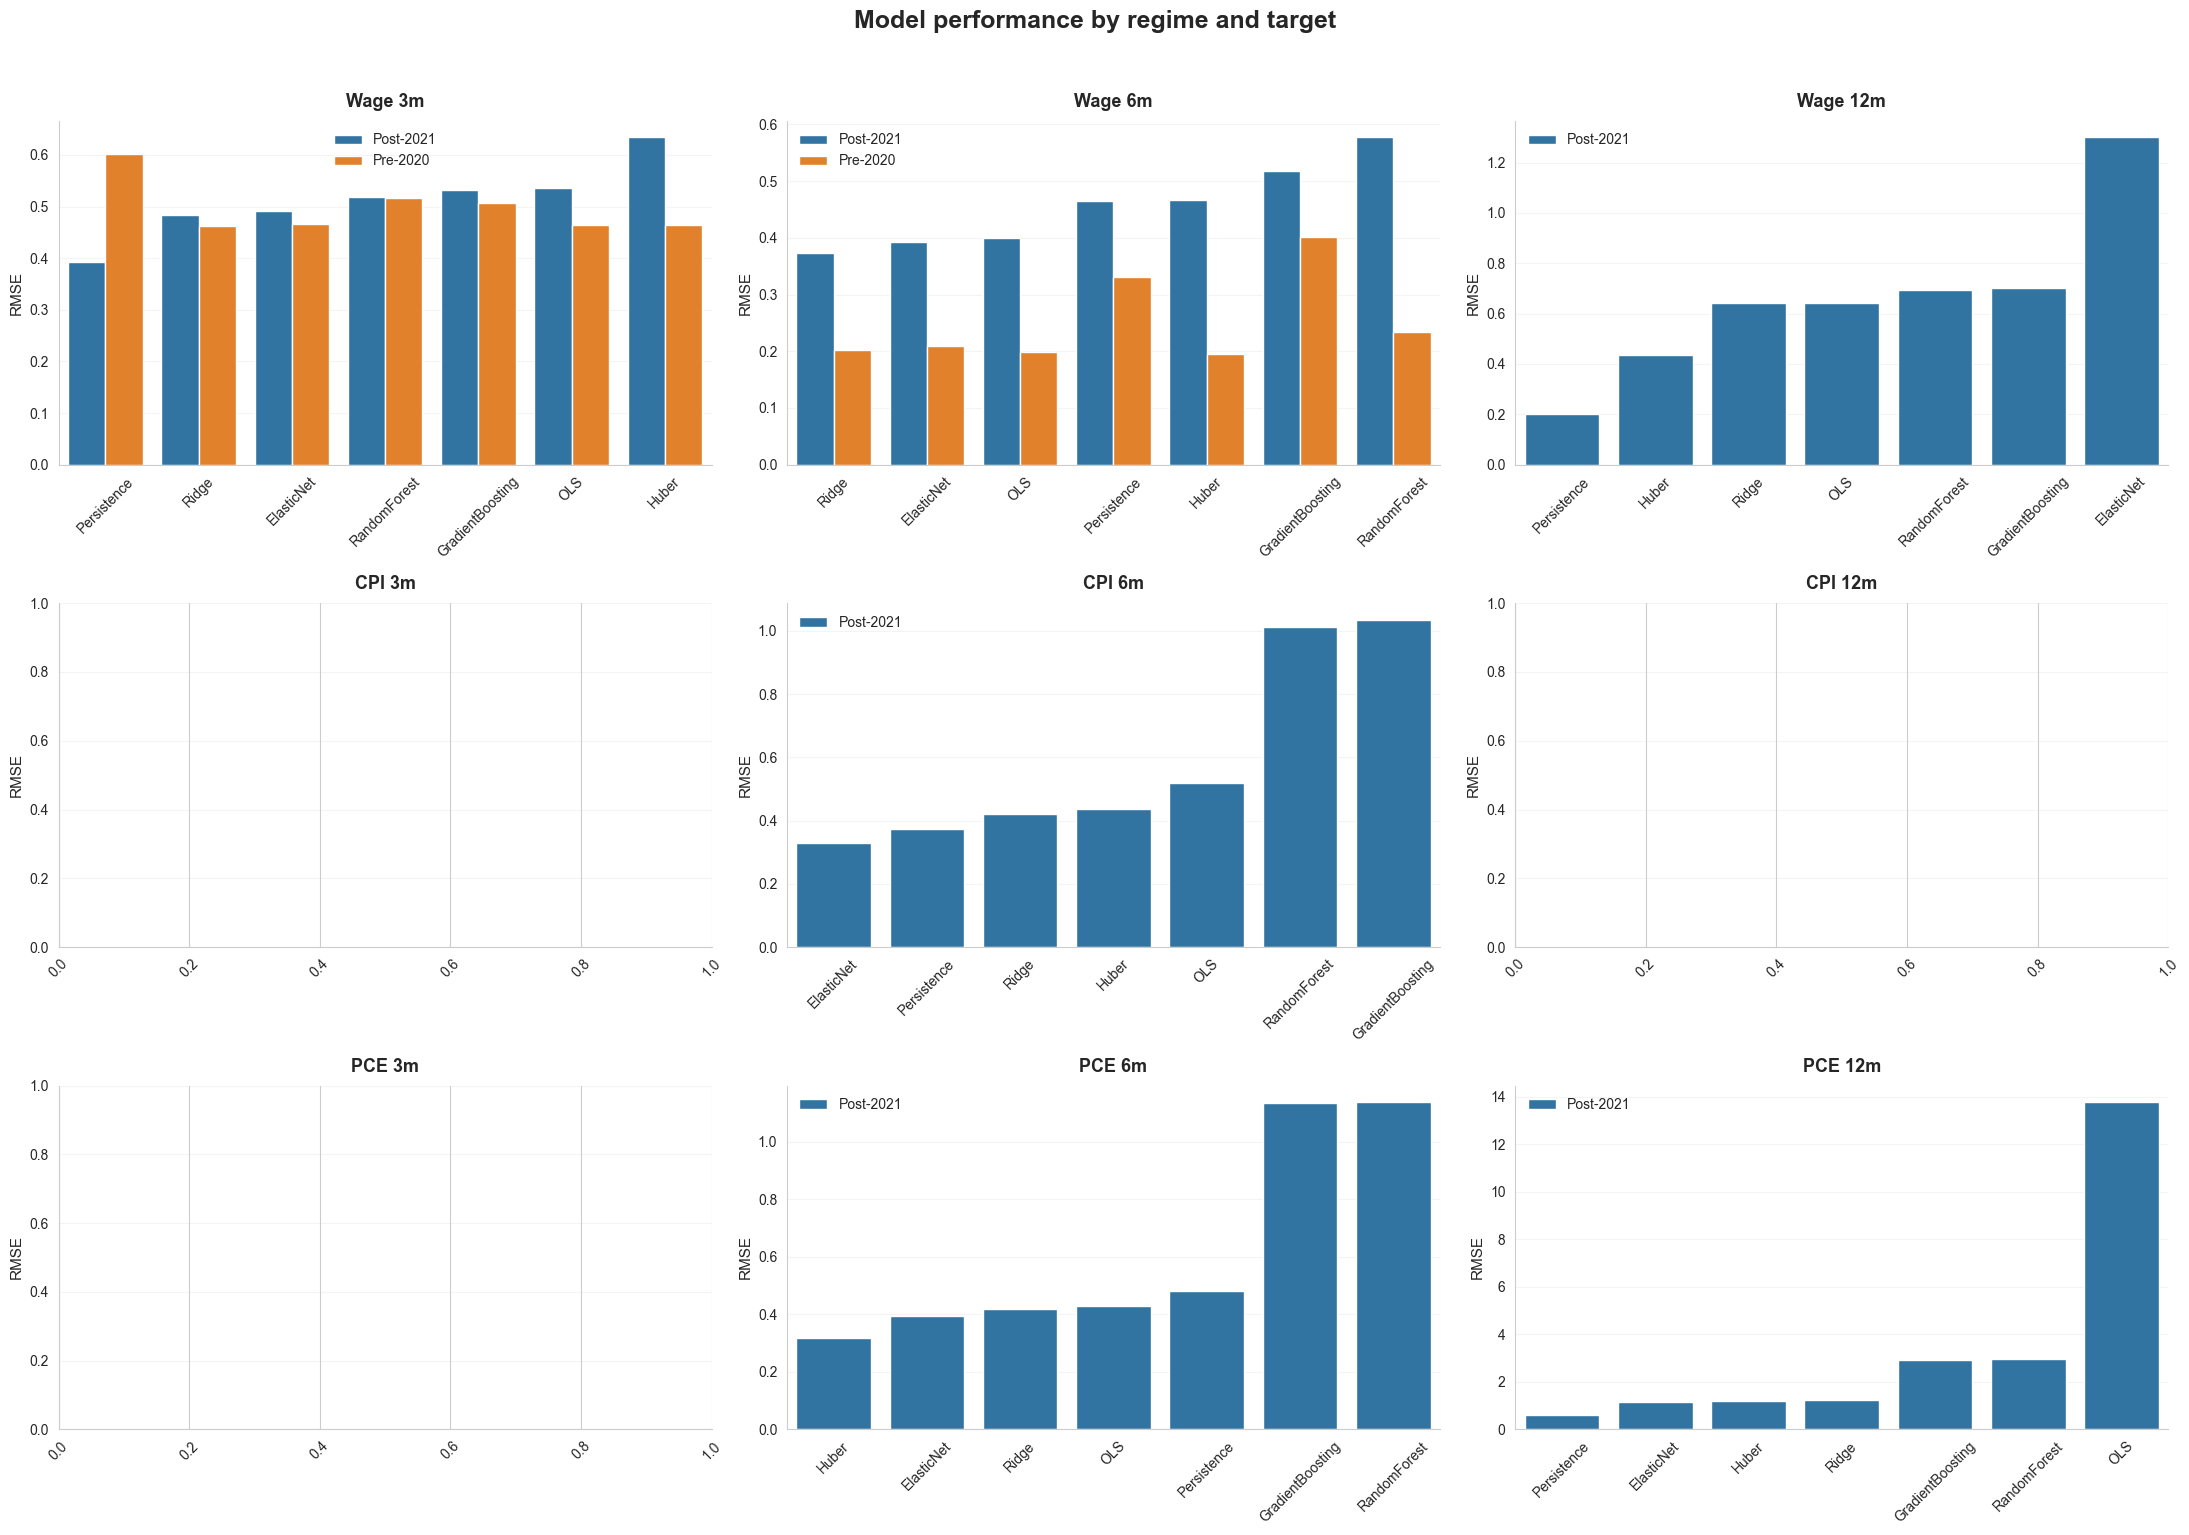

In [55]:
plot_data = metric_data.copy()
plot_data["regime_label"] = plot_data["regime"].map({"pre": "Pre-2020", "post": "Post-2021"})

fig, axes = plt.subplots(3, 3, figsize=(22, 15), sharey=False)
axes = axes.ravel()

for ax, target_col in zip(axes, all_targets):
    part = plot_data.loc[plot_data["target_col"].eq(target_col)].copy()
    part = part.sort_values(["regime_label", "rmse", "model"]).reset_index(drop=True)

    sns.barplot(
        data=part,
        x="model",
        y="rmse",
        hue="regime_label",
        ax=ax,
    )

    ax.set_title(target_label(target_col), fontsize=13, pad=10, weight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("RMSE", fontsize=11)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, axis="y", alpha=0.20)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if ax.get_legend() is not None:
        ax.get_legend().set_title("")
        ax.get_legend().set_frame_on(False)

for ax in axes[len(all_targets):]:
    ax.set_axis_off()

fig.suptitle(
    "Model performance by regime and target",
    fontsize=18,
    weight="bold",
    y=1.02,
)
fig.tight_layout()
fig.savefig(fig_root / "results_and_audit_model_comparison.png", dpi=save_dpi, bbox_inches="tight")
plt.show()

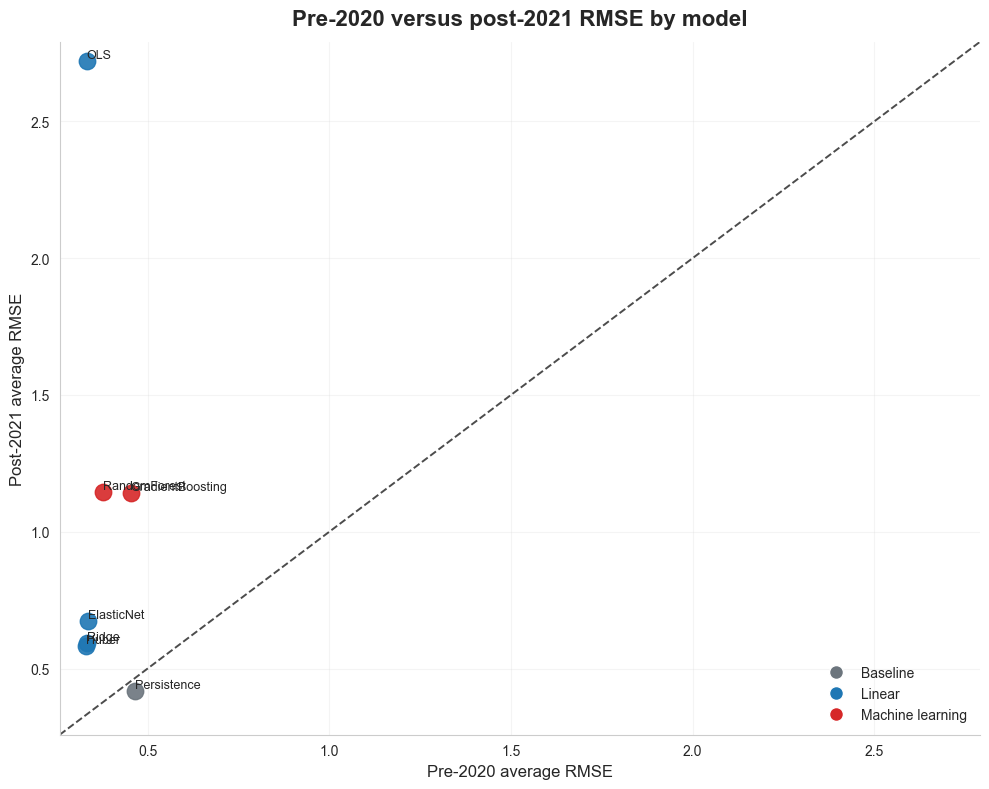

In [56]:
scatter_data = (
    metric_data.groupby(["model", "regime"], as_index=False)
    .agg(
        rmse=("rmse", "mean"),
    )
    .pivot(index="model", columns="regime", values="rmse")
    .reset_index()
)

scatter_data["group"] = "Baseline"
scatter_data.loc[scatter_data["model"].isin(linear_list), "group"] = "Linear"
scatter_data.loc[scatter_data["model"].isin(tree_list), "group"] = "Machine learning"

color_map = {
    "Baseline": "#6c757d",
    "Linear": "#1f77b4",
    "Machine learning": "#d62728",
}

fig, ax = plt.subplots(figsize=(10, 8))

for _, row in scatter_data.iterrows():
    ax.scatter(
        row["pre"],
        row["post"],
        s=140,
        color=color_map[row["group"]],
        alpha=0.90,
    )
    ax.text(
        row["pre"],
        row["post"],
        row["model"],
        fontsize=9,
        ha="left",
        va="bottom",
    )

low = min(scatter_data["pre"].min(), scatter_data["post"].min())
high = max(scatter_data["pre"].max(), scatter_data["post"].max())

pad = 0.03 * (high - low)
ax.plot(
    [low - pad, high + pad],
    [low - pad, high + pad],
    linestyle="--",
    linewidth=1.4,
    color="black",
    alpha=0.7,
)

ax.set_xlim(low - pad, high + pad)
ax.set_ylim(low - pad, high + pad)
ax.set_title("Pre-2020 versus post-2021 RMSE by model", fontsize=16, pad=12, weight="bold")
ax.set_xlabel("Pre-2020 average RMSE", fontsize=12)
ax.set_ylabel("Post-2021 average RMSE", fontsize=12)
ax.grid(True, alpha=0.20)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

handles = []
labels = []
for group_name, color in color_map.items():
    handle = plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=color, markersize=10)
    handles.append(handle)
    labels.append(group_name)

ax.legend(handles, labels, frameon=False, title="")

fig.tight_layout()
fig.savefig(fig_root / "results_and_audit_linear_vs_ml.png", dpi=save_dpi, bbox_inches="tight")
plt.show()

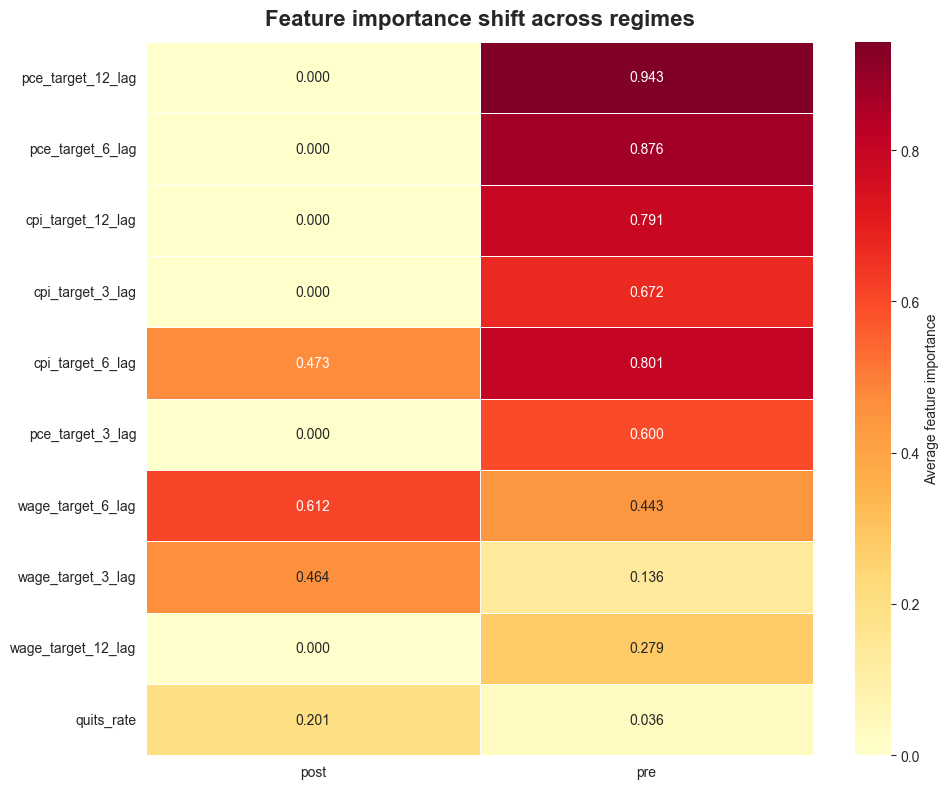

In [57]:
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    imp_heat,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Average feature importance"},
    ax=ax,
)

ax.set_title("Feature importance shift across regimes", fontsize=16, pad=12, weight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=0)
ax.tick_params(axis="y", rotation=0)

fig.tight_layout()
fig.savefig(fig_root / "results_and_audit_feature_shift.png", dpi=save_dpi, bbox_inches="tight")
plt.show()

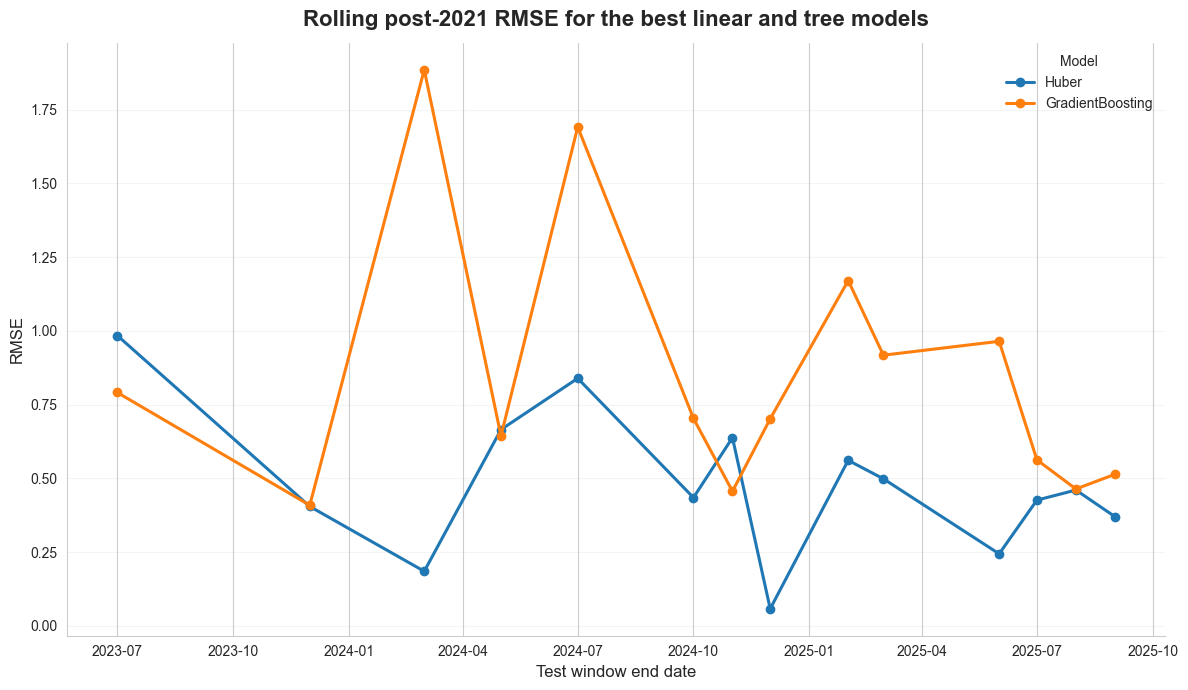

In [58]:
best_linear = (
    metric_data.loc[metric_data["regime"].eq("post") & metric_data["model"].isin(linear_list)]
    .groupby("model", as_index=False)
    .agg(rmse=("rmse", "mean"))
    .sort_values("rmse")
    .iloc[0]["model"]
)

best_tree = (
    metric_data.loc[metric_data["regime"].eq("post") & metric_data["model"].isin(tree_list)]
    .groupby("model", as_index=False)
    .agg(rmse=("rmse", "mean"))
    .sort_values("rmse")
    .iloc[0]["model"]
)

plot_linear = (
    rolling_data.loc[rolling_data["model"].eq(best_linear)]
    .groupby("test_end", as_index=False)
    .agg(rmse=("rmse", "mean"))
)

plot_tree = (
    rolling_data.loc[rolling_data["model"].eq(best_tree)]
    .groupby("test_end", as_index=False)
    .agg(rmse=("rmse", "mean"))
)

fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(
    plot_linear["test_end"],
    plot_linear["rmse"],
    marker="o",
    linewidth=2.2,
    label=best_linear,
)

ax.plot(
    plot_tree["test_end"],
    plot_tree["rmse"],
    marker="o",
    linewidth=2.2,
    label=best_tree,
)

ax.set_title("Rolling post-2021 RMSE for the best linear and tree models", fontsize=16, pad=12, weight="bold")
ax.set_xlabel("Test window end date", fontsize=12)
ax.set_ylabel("RMSE", fontsize=12)
ax.grid(True, axis="y", alpha=0.20)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, title="Model")

fig.tight_layout()
fig.savefig(fig_root / "results_and_audit_rolling_rmse.png", dpi=save_dpi, bbox_inches="tight")
plt.show()

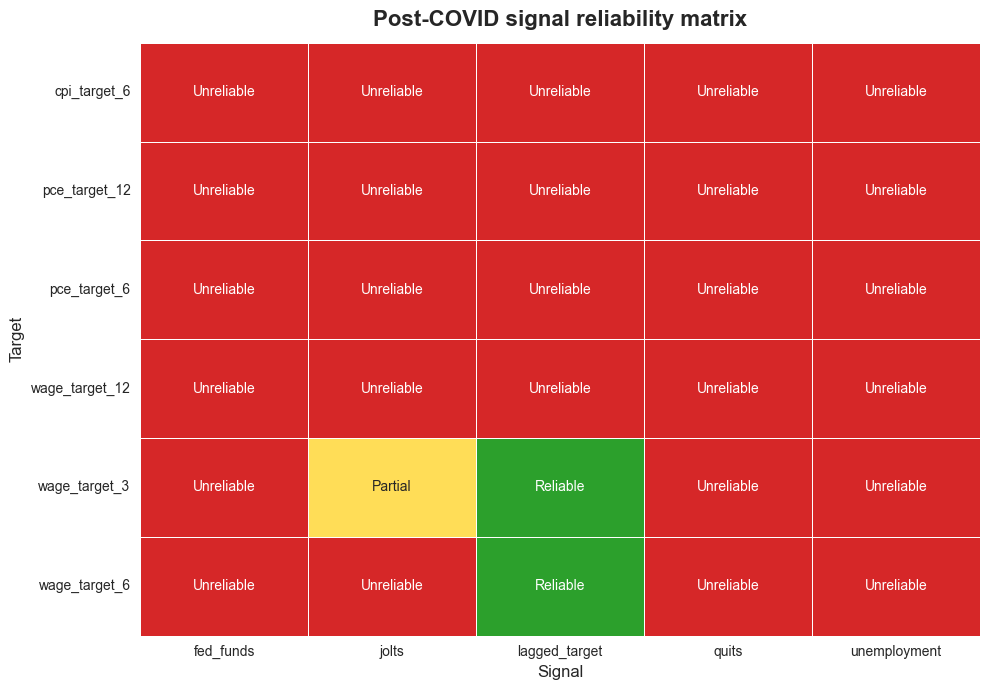

In [59]:
fig, ax = plt.subplots(figsize=(10, 7))

sns.heatmap(
    reliability_matrix,
    annot=reliability_text,
    fmt="",
    cmap=ListedColormap(["#d62728", "#ffdd57", "#2ca02c"]),
    cbar=False,
    linewidths=0.5,
    linecolor="white",
    ax=ax,
)

ax.set_title("Post-COVID signal reliability matrix", fontsize=16, pad=12, weight="bold")
ax.set_xlabel("Signal", fontsize=12)
ax.set_ylabel("Target", fontsize=12)
ax.tick_params(axis="x", rotation=0)
ax.tick_params(axis="y", rotation=0)

fig.tight_layout()
fig.savefig(fig_root / "results_and_audit_reliability_matrix.png", dpi=save_dpi, bbox_inches="tight")
plt.show()

In [51]:
metric_data.to_csv(report_root / "results_and_audit_metrics.csv", index=False)
pre_best.to_csv(report_root / "results_and_audit_pre_best.csv", index=False)
post_best.to_csv(report_root / "results_and_audit_post_best.csv", index=False)
direct_compare.to_csv(report_root / "results_and_audit_direct_compare.csv", index=False)
transfer_data.to_csv(report_root / "results_and_audit_transfer.csv", index=False)
group_summary.to_csv(report_root / "results_and_audit_group_summary.csv", index=False)
linear_ml_compare.to_csv(report_root / "results_and_audit_linear_ml_compare.csv", index=False)
rolling_data.to_csv(report_root / "results_and_audit_rolling_data.csv", index=False)
rolling_cv.to_csv(report_root / "results_and_audit_rolling_cv.csv", index=False)
coef_data.to_csv(report_root / "results_and_audit_coefficients.csv", index=False)
coef_compare.to_csv(report_root / "results_and_audit_jolts_coefficients.csv", index=False)
imp_mean.to_csv(report_root / "results_and_audit_feature_importance.csv", index=False)
imp_compare.to_csv(report_root / "results_and_audit_feature_top_compare.csv", index=False)
signal_metric.to_csv(report_root / "results_and_audit_signal_metrics.csv", index=False)
signal_coef_data.to_csv(report_root / "results_and_audit_signal_coefficients.csv", index=False)
reliability_data.to_csv(report_root / "results_and_audit_reliability.csv", index=False)
model_compare.to_csv(report_root / "results_and_audit_model_compare.csv", index=False)
model_change.to_csv(report_root / "results_and_audit_model_change.csv", index=False)
sample_data.to_csv(report_root / "results_and_audit_sample_data.csv", index=False)
regime_scores.to_csv(report_root / "results_and_audit_regime_scores.csv", index=False)
regime_preds.to_csv(model_root / "results_and_audit_regime_predictions.csv", index=False)

In [52]:
display(metric_data.round(show_dec))
display(pre_best.round(show_dec))
display(post_best.round(show_dec))
display(direct_compare.round(show_dec))
display(group_summary.round(show_dec))
display(linear_ml_compare.round(show_dec))
display(coef_compare.round(show_dec))
display(imp_compare.round(show_dec))
display(reliability_data.round(show_dec))
display(model_change.round(show_dec))
display(sample_data.round(show_dec))
display(rolling_cv.round(show_dec))

,target,target_col,horizon,model,regime,rmse,mae,oos_r2,row_count,fold_count
0,CPI,cpi_target_6,6,ElasticNet,post,0.3287,0.3287,0.3228,4,4
1,CPI,cpi_target_6,6,Persistence,post,0.3745,0.3745,0.0000,4,4
2,CPI,cpi_target_6,6,Ridge,post,0.4222,0.4222,-1.0232,4,4
3,CPI,cpi_target_6,6,Huber,post,0.4362,0.4362,-1.7445,4,4
4,CPI,cpi_target_6,6,OLS,post,0.5172,0.5172,-3.7802,4,4
5,CPI,cpi_target_6,6,RandomForest,post,1.0129,1.0129,-7.3752,4,4
6,CPI,cpi_target_6,6,GradientBoosting,post,1.0355,1.0355,-7.7425,4,4
7,PCE,pce_target_6,6,Huber,post,0.3183,0.3183,-0.0419,3,3
8,PCE,pce_target_6,6,ElasticNet,post,0.3934,0.3934,-0.2595,3,3
9,PCE,pce_target_6,6,Ridge,post,0.4184,0.4184,-0.3988,3,3


,target_col,target,horizon,model,regime,rmse,mae,oos_r2,row_count,fold_count
0,wage_target_3,Wage,3,Ridge,pre,0.4634,0.3808,0.4034,28,2
1,wage_target_6,Wage,6,Huber,pre,0.1953,0.1749,0.6518,11,1


,target_col,target,horizon,model,regime,rmse,mae,oos_r2,row_count,fold_count
0,cpi_target_6,CPI,6,ElasticNet,post,0.3287,0.3287,0.3228,4,4
1,pce_target_6,PCE,6,Huber,post,0.3183,0.3183,-0.0419,3,3
2,pce_target_12,PCE,12,Persistence,post,0.6006,0.5916,0.0000,3,1
3,wage_target_3,Wage,3,Persistence,post,0.3928,0.3353,0.0000,8,4
4,wage_target_6,Wage,6,Ridge,post,0.3724,0.3152,0.1727,10,5
5,wage_target_12,Wage,12,Persistence,post,0.1998,0.1934,0.0000,5,1


,target,target_col,horizon,pre_model,pre_rmse,pre_mae,pre_oos_r2,post_model,post_rmse,post_mae,post_oos_r2,rmse_change_pct,mae_change_pct
0,NaN,cpi_target_6,NaN,NaN,NaN,NaN,NaN,ElasticNet,0.3287,0.3287,0.3228,NaN,NaN
1,NaN,pce_target_12,NaN,NaN,NaN,NaN,NaN,Persistence,0.6006,0.5916,0.0000,NaN,NaN
2,NaN,pce_target_6,NaN,NaN,NaN,NaN,NaN,Huber,0.3183,0.3183,-0.0419,NaN,NaN
3,NaN,wage_target_12,NaN,NaN,NaN,NaN,NaN,Persistence,0.1998,0.1934,0.0000,NaN,NaN
4,Wage,wage_target_3,3.0000,Ridge,0.4634,0.3808,0.4034,Persistence,0.3928,0.3353,0.0000,-15.2343,-11.9392
5,Wage,wage_target_6,6.0000,Huber,0.1953,0.1749,0.6518,Ridge,0.3724,0.3152,0.1727,90.6965,80.1675


,regime,group,mean_rmse,mean_mae,mean_oos_r2
0,post,baseline,0.4188,0.3997,0.0000
1,post,linear,1.1422,1.0984,-25.5703
2,post,machine_learning,1.1447,1.1271,-8.6859
3,pre,baseline,0.4667,0.3729,0.0000
4,pre,linear,0.3329,0.2777,0.5154
5,pre,machine_learning,0.4150,0.3278,0.1302


...

,pre_feature,regime,pre_importance,post_feature,regime,post_importance
0,pce_target_12_lag,pre,0.9433,wage_target_6_lag,post,0.6120
1,pce_target_6_lag,pre,0.8762,cpi_target_6_lag,post,0.4731
2,cpi_target_6_lag,pre,0.8009,wage_target_3_lag,post,0.4639
3,cpi_target_12_lag,pre,0.7908,quits_rate,post,0.2012
4,cpi_target_3_lag,pre,0.6718,fed_funds,post,0.0898


,target,target_col,horizon,signal,mae_post,mae_pre,oos_r2_post,oos_r2_pre,rmse_post,rmse_pre,coefficient_post,coefficient_pre,p_value_post,p_value_pre,t_value_post,t_value_pre,rmse_change_pct,sign_same,coef_ratio,reliability,flag
0,CPI,cpi_target_6,6,fed_funds,0.2750,NaN,0.3590,NaN,0.2750,NaN,-0.1764,0.0059,0.0187,0.9034,-2.3508,0.1213,NaN,False,29.7872,Unreliable,0
1,CPI,cpi_target_6,6,jolts,0.5172,NaN,-3.7802,NaN,0.5172,NaN,-0.7009,-0.5176,0.3944,0.0001,-0.8516,-3.9733,NaN,True,1.3542,Unreliable,0
2,CPI,cpi_target_6,6,lagged_target,0.2517,NaN,0.5642,NaN,0.2517,NaN,0.9537,0.8741,0.0000,0.0000,47.3452,27.7073,NaN,True,1.0910,Unreliable,0
3,CPI,cpi_target_6,6,quits,0.3235,NaN,0.0272,NaN,0.3235,NaN,0.8318,-1.2231,0.2361,0.0011,1.1847,-3.2614,NaN,False,0.6801,Unreliable,0
4,CPI,cpi_target_6,6,unemployment,0.2845,NaN,0.3024,NaN,0.2845,NaN,0.3482,0.1440,0.3953,0.0003,0.8501,3.6392,NaN,True,2.4177,Unreliable,0
5,PCE,pce_target_12,12,fed_funds,83.9350,NaN,"-19,862.8058",NaN,84.6545,NaN,0.3838,-0.0578,0.0042,0.0002,2.8611,-3.7067,NaN,False,6.6446,Unreliable,0
6,PCE,pce_target_12,12,jolts,13.7754,NaN,-526.2488,NaN,13.7920,NaN,-1.9496,0.1954,0.0000,0.0010,-4.7259,3.2999,NaN,False,9.9778,Unreliable,0
7,PCE,pce_target_12,12,lagged_target,1.7935,NaN,-7.9521,NaN,1.7971,NaN,0.9135,0.9200,0.0000,0.0000,19.7358,18.6636,NaN,True,0.9930,Unreliable,0
8,PCE,pce_target_12,12,quits,100.7742,NaN,"-28,604.4866",NaN,101.5882,NaN,-1.9070,0.5256,0.0054,0.0000,-2.7802,4.7354,NaN,False,3.6284,Unreliable,0
9,PCE,pce_target_12,12,unemployment,5.8555,NaN,-94.0596,NaN,5.8562,NaN,0.6688,-0.0539,0.0000,0.0054,8.5275,-2.7804,NaN,False,12.4058,Unreliable,0


,model,mean_pre_rmse,mean_post_rmse,mean_rmse_change_pct,mean_pre_mae,mean_post_mae,mean_mae_change_pct
0,Persistence,0.4667,0.4188,2.7763,0.3729,0.3997,18.0924
1,GradientBoosting,0.4539,1.1423,16.9963,0.3706,1.1237,28.5930
2,Ridge,0.3325,0.5940,44.6022,0.2779,0.5386,49.1487
3,ElasticNet,0.3372,0.6729,46.6925,0.2789,0.6268,53.8589
4,OLS,0.3321,2.7192,57.6695,0.2790,2.6980,64.2346
5,RandomForest,0.3761,1.1470,72.9867,0.2851,1.1305,100.8473
6,Huber,0.3299,0.5828,87.5993,0.2748,0.5304,93.4551


,target,target_col,horizon,rows,pre_rows,post_rows,pre_start,pre_end,post_start,post_end,feature_count
0,Wage,wage_target_3,3,109,87,16,2006-06-01,2019-08-01,2021-09-01,2025-09-01,4
1,Wage,wage_target_6,6,94,67,18,2006-07-01,2019-11-01,2021-06-01,2025-09-01,4
2,Wage,wage_target_12,12,37,22,9,2007-10-01,2019-05-01,2021-07-01,2024-10-01,4
3,CPI,cpi_target_3,3,31,26,4,2001-05-01,2019-12-01,2021-12-01,2025-01-01,4
4,CPI,cpi_target_6,6,48,33,12,2001-04-01,2019-12-01,2021-06-01,2025-08-01,4
5,CPI,cpi_target_12,12,42,35,5,2001-07-01,2019-11-01,2022-04-01,2024-08-01,4
6,PCE,pce_target_3,3,31,26,2,2001-02-01,2019-10-01,2025-03-01,2025-06-01,4
7,PCE,pce_target_6,6,53,39,11,2001-06-01,2019-06-01,2021-10-01,2025-07-01,4
8,PCE,pce_target_12,12,47,37,7,2001-08-01,2019-11-01,2021-06-01,2024-07-01,4


,target,target_col,horizon,model,mean_rmse,std_rmse,min_rmse,max_rmse,row_count,cv_rmse
0,CPI,cpi_target_6,6,ElasticNet,0.3287,0.3012,0.0974,0.7648,4,0.9163
1,CPI,cpi_target_6,6,GradientBoosting,1.0355,0.6225,0.4642,1.8852,4,0.6012
2,CPI,cpi_target_6,6,Huber,0.4362,0.4367,0.0582,1.0409,4,1.0011
3,CPI,cpi_target_6,6,OLS,0.5172,0.4772,0.0762,1.1381,4,0.9226
4,CPI,cpi_target_6,6,Persistence,0.3745,0.1971,0.1646,0.6073,4,0.5263
5,CPI,cpi_target_6,6,RandomForest,1.0129,0.6451,0.4317,1.9063,4,0.6369
6,CPI,cpi_target_6,6,Ridge,0.4222,0.1562,0.3108,0.6522,4,0.3699
7,PCE,pce_target_12,12,ElasticNet,1.1320,NaN,1.1320,1.1320,1,NaN
8,PCE,pce_target_12,12,GradientBoosting,2.9304,NaN,2.9304,2.9304,1,NaN
9,PCE,pce_target_12,12,Huber,1.2070,NaN,1.2070,1.2070,1,NaN
